<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/26Simple_linear_regression_practice_problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default styles for our plots
sns.set_theme()

In [2]:
X = np.array([1 , 3, 4, 6, 7]) # Input feature: years of experience
y = np.array([15,35,45,65,75]) # Target value: salary (in thousands)

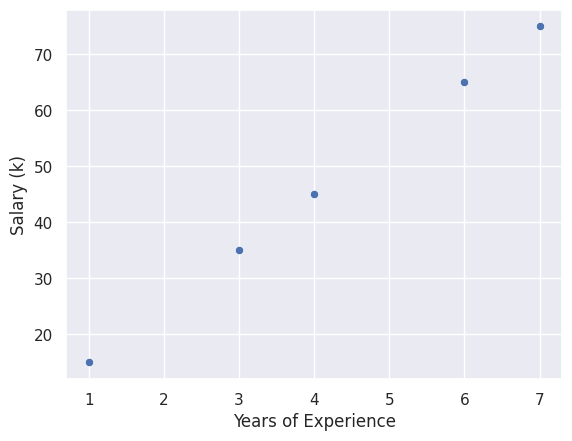

In [3]:
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.show()

In [4]:
def make_prediction(X, y, w, b):
  m = X.shape[0]

  pred_list = np.zeros((m,))

  for i in range(m):
    pred_list[i] = w * X[i] + b

  return pred_list

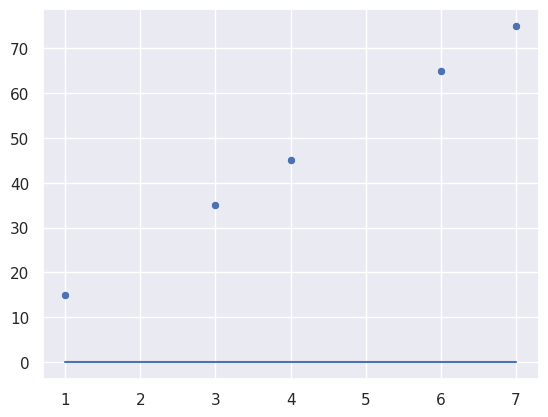

In [5]:
predictions = make_prediction(X, y, 0, 0)

sns.scatterplot(x = X, y = y)
plt.plot(X, predictions)

In [6]:
def compute_cost(X,y, w, b):
  m = X.shape[0]
  cost = 0.0
  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    error_squared = error ** 2
    cost = cost + error_squared

  cost = cost / (2*m)
  return cost

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 0.0, for w =10.0 and b=5.0')

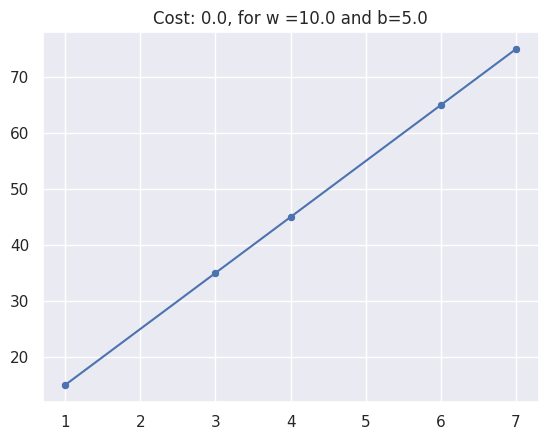

In [7]:
w= 10.0
b= 5.0

predictions = make_prediction(X,y,w=w,b=b)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w ={w} and b={b}")

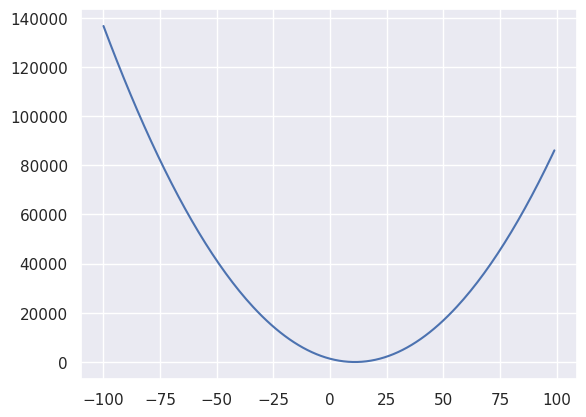

In [8]:
w_range = []
cost_history = []

for i in range(-100, 100):
  cost_i = compute_cost(X, y, w = i, b = 0)
  w_range.append(i)
  cost_history.append(cost_i)

plt.plot(w_range, cost_history)

In [9]:
def calculate_gradient(X, y, w, b):
  m = X.shape[0]
  dj_dw = 0.0
  dj_db = 0.0

  for i in range(m):
    prediction = w * X[i] + b
    error = prediction - y[i]
    dj_dw = dj_dw + error * X[i]
    dj_db = dj_db + error

  return dj_dw / m, dj_db / m

In [10]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha = 0.01):
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
    dj_dw, dj_db = calculate_gradient(X,y, w, b)

    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(X,y, w,b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f}, w: {w:0.4f}, b: {b:0.4f}")

  return w,b,cost_memo, iteration

In [11]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=0, b_input=0, max_iter=10000, alpha=0.01)

Iteration 0: Cost 790.3717, w: 2.4300, b: 0.4700
Iteration 100: Cost 0.6120, w: 10.4659, b: 2.5593
Iteration 200: Cost 0.4115, w: 10.3821, b: 2.9986
Iteration 300: Cost 0.2767, w: 10.3133, b: 3.3588
Iteration 400: Cost 0.1861, w: 10.2569, b: 3.6542
Iteration 500: Cost 0.1251, w: 10.2107, b: 3.8965
Iteration 600: Cost 0.0841, w: 10.1727, b: 4.0951
Iteration 700: Cost 0.0566, w: 10.1416, b: 4.2580
Iteration 800: Cost 0.0380, w: 10.1162, b: 4.3915
Iteration 900: Cost 0.0256, w: 10.0952, b: 4.5010
Iteration 1000: Cost 0.0172, w: 10.0781, b: 4.5909
Iteration 1100: Cost 0.0116, w: 10.0640, b: 4.6645
Iteration 1200: Cost 0.0078, w: 10.0525, b: 4.7249
Iteration 1300: Cost 0.0052, w: 10.0431, b: 4.7744
Iteration 1400: Cost 0.0035, w: 10.0353, b: 4.8150
Iteration 1500: Cost 0.0024, w: 10.0290, b: 4.8483
Iteration 1600: Cost 0.0016, w: 10.0237, b: 4.8756
Iteration 1700: Cost 0.0011, w: 10.0195, b: 4.8980
Iteration 1800: Cost 0.0007, w: 10.0160, b: 4.9164
Iteration 1900: Cost 0.0005, w: 10.0131, b

Optimized w: 10.0000, b: 5.0000


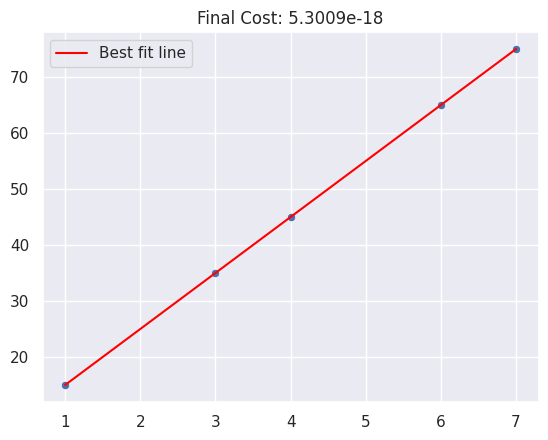

In [12]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Get final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [13]:
# Example: Predicting salary for someone with 2 years of experience
x_new = 2

# Using the formula f(x) = wx + b with our final calculated parameters
prediction = w_final * x_new + b_final
print(f"Predicted salary for {x_new} years of experience: {prediction:0.2f}k")

Predicted salary for 2 years of experience: 25.00k


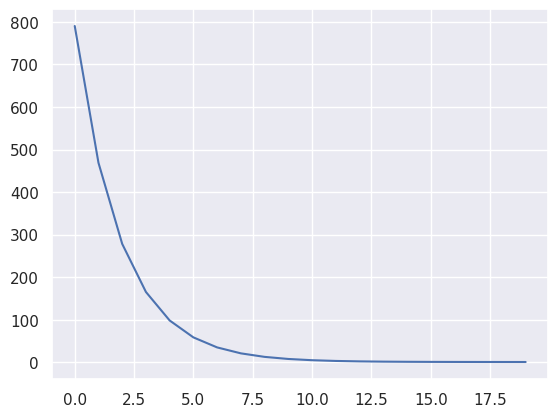

In [14]:
plt.plot(iter_list[:20], cost_memo[:20])

Load the dataset using Pandas.

Select one feature (e.g., area) and the target variable (price). And convert them to numpy array

Implement the Mean Squared Error (MSE) Cost Function manually.

Calculate the initial cost using random values of slope and intercept.

Apply Gradient Descent from scratch.

Train for 1000 iterations.

Plot:

Iteration vs Cost

Actual vs Predicted Values

Report the final learned parameters.


In [15]:
import pandas as pd

In [16]:
df = pd.read_csv('/content/Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [17]:
X = np.array(df['area'])
y = np.array(df['price'])

In [18]:
from sklearn.preprocessing import StandardScaler

# Reshape X and y for StandardScaler (expects 2D array)
X_reshaped = X.reshape(-1, 1)
y_reshaped = y.reshape(-1, 1)

# Initialize StandardScaler for X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# Fit and transform X and y
X_scaled = scaler_X.fit_transform(X_reshaped)
y_scaled = scaler_y.fit_transform(y_reshaped)

# Flatten back to 1D arrays for compatibility with existing functions
X_scaled = X_scaled.flatten()
y_scaled = y_scaled.flatten()

print("X_scaled (first 5 values):", X_scaled[:5])
print("y_scaled (first 5 values):", y_scaled[:5])

X_scaled (first 5 values): [1.04672629 1.75700953 2.21823241 1.08362412 1.04672629]
y_scaled (first 5 values): [4.56636513 4.00448405 4.00448405 3.98575468 3.55497918]


In [19]:
np.random.seed(1)
w_initial = np.random.rand()
b_initial = np.random.rand()

cost = compute_cost(X_scaled, y_scaled, w_initial, b_initial)

print(f'Initial cost with random values of slope and intercept {cost}')

Initial cost with random values of slope and intercept 0.6228646764777935


In [20]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X_scaled, y_scaled, w_initial, b_initial, max_iter=1000, alpha=0.01)

print(f'W_final {w_final} b_final {b_final}')

Iteration 0: Cost 0.6176, w: 0.4182, b: 0.7131
Iteration 100: Cost 0.3913, w: 0.4929, b: 0.2610
Iteration 200: Cost 0.3610, w: 0.5202, b: 0.0955
Iteration 300: Cost 0.3570, w: 0.5302, b: 0.0350
Iteration 400: Cost 0.3564, w: 0.5339, b: 0.0128
Iteration 500: Cost 0.3564, w: 0.5352, b: 0.0047
Iteration 600: Cost 0.3564, w: 0.5357, b: 0.0017
Iteration 700: Cost 0.3564, w: 0.5359, b: 0.0006
Iteration 800: Cost 0.3564, w: 0.5360, b: 0.0002
Iteration 900: Cost 0.3564, w: 0.5360, b: 0.0001
W_final 0.5359922094641946 b_final 3.109730692261681e-05


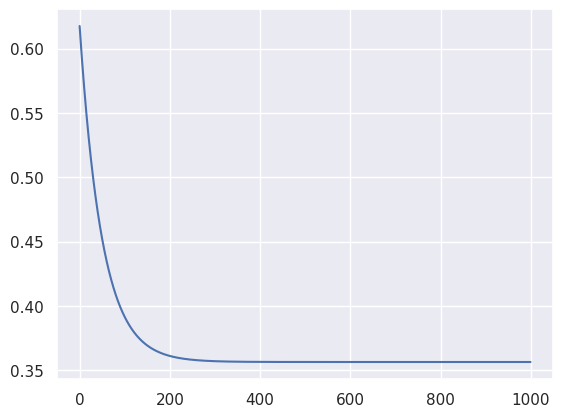

In [21]:
plt.plot(iter_list, cost_memo)
plt.show()

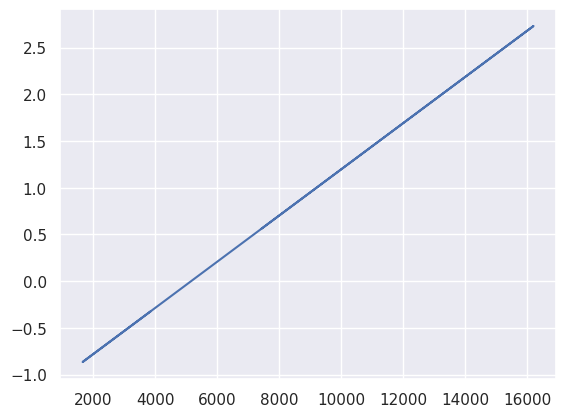

In [22]:
prediction = make_prediction(X_scaled, y_scaled, w_final, b_final)

plt.plot(X, prediction)
plt.show()

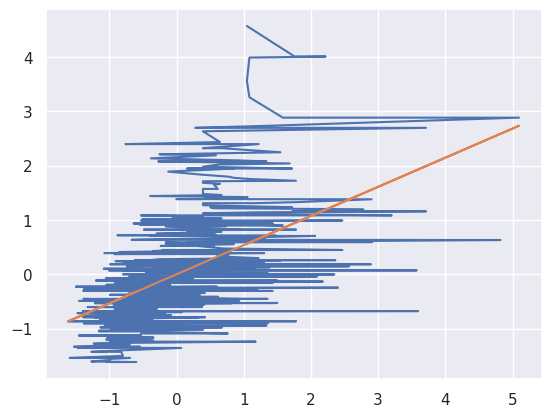

In [23]:
plt.plot(X_scaled,y_scaled)
plt.plot(X_scaled, prediction)
plt.show()

In [24]:
print(f'Weights final {w_final} bias final {b_final}')

Weights final 0.5359922094641946 bias final 3.109730692261681e-05


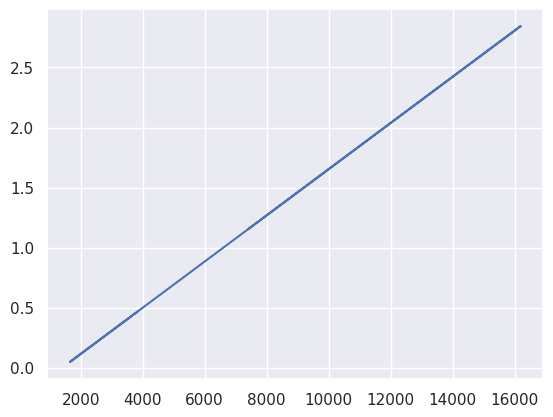

In [25]:
prediction = make_prediction(X_scaled, y_scaled, w_initial, b_initial)

plt.plot(X, prediction)
plt.show()

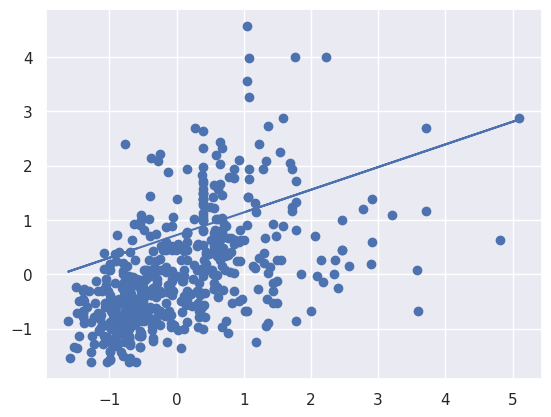

In [26]:
plt.scatter(X_scaled,y_scaled)
plt.plot(X_scaled, prediction)
plt.show()

Predict Salary from YearsExperience.

Initialize parameters randomly.

Calculate cost before training.

Apply Gradient Descent.

Plot:

Cost vs Iteration

Regression Line

In [27]:
df = pd.read_csv('/content/Salary_Data.csv')

df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [28]:
from sklearn.compose import ColumnTransformer

In [29]:
encoder_scaler = ColumnTransformer(
    transformers=[
        ('YearsExperience',StandardScaler(),['YearsExperience','Salary'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
encoder_scaler.set_output(transform='pandas')

encoder_scaler.fit(df)

df = encoder_scaler.transform(df)

In [30]:
X = np.array(df['YearsExperience'])
y = np.array(df['Salary'])

In [31]:
df

,YearsExperience,Salary
0,-1.510053,-1.360113
1,-1.438373,-1.105527
2,-1.366693,-1.419919
3,-1.187494,-1.204957
4,-1.115814,-1.339781
5,-0.864935,-0.718307
6,-0.829096,-0.588158
7,-0.757416,-0.799817
8,-0.757416,-0.428810
9,-0.578216,-0.698013


In [32]:
np.random.seed(1)
w_initial = np.random.rand()
b_initial = np.random.rand()

In [33]:
initial_cost = compute_cost(X, y, w_initial, b_initial)
print(f'Initial cost {initial_cost}')

Initial cost 0.4384390833037545


In [34]:
w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_initial, b_initial, max_iter=10000, alpha=0.01)

print(f'W_final {w_final} b_final {b_final}')

Iteration 0: Cost 0.4301, w: 0.4226, b: 0.7131
Iteration 100: Cost 0.0763, w: 0.7749, b: 0.2610
Iteration 200: Cost 0.0289, w: 0.9038, b: 0.0955
Iteration 300: Cost 0.0225, w: 0.9510, b: 0.0350
Iteration 400: Cost 0.0217, w: 0.9683, b: 0.0128
Iteration 500: Cost 0.0215, w: 0.9746, b: 0.0047
Iteration 600: Cost 0.0215, w: 0.9769, b: 0.0017
Iteration 700: Cost 0.0215, w: 0.9778, b: 0.0006
Iteration 800: Cost 0.0215, w: 0.9781, b: 0.0002
Iteration 900: Cost 0.0215, w: 0.9782, b: 0.0001
Iteration 1000: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1100: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1200: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1300: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1400: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1500: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1600: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1700: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1800: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 1900: Cost 0.0215, w: 0.9782, b: 0.0000
Iteration 20

Optimized w: 0.9782, b: 0.0000


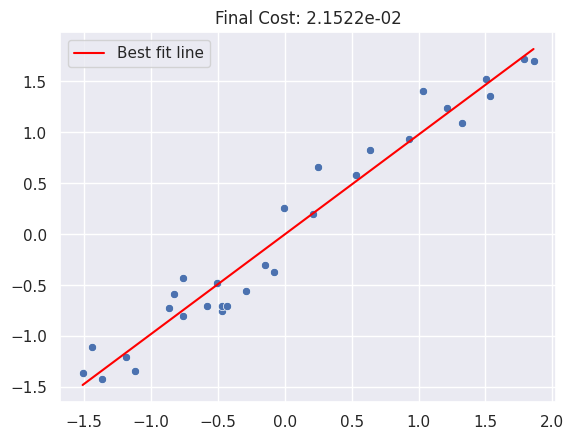

In [35]:
print(f"Optimized w: {w_final:0.4f}, b: {b_final:0.4f}")

# Get final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_final, b=b_final)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {compute_cost(X, y, w_final, b_final):0.4e}")
plt.legend()
plt.show()

In [36]:
import pandas as pd

# Define headers parsed from the .names file documentation
columns = [
    "mpg", "cylinders", "displacement", "horsepower",
    "weight", "acceleration", "model_year", "origin", "car_name"
]

# Read the file directly using read_csv
df = pd.read_csv(
    "/content/auto-mpg.data",
    sep=r"\s+",         # Handles variable whitespace separations
    names=columns,      # Manually injects the column headers
    na_values="?"       # Converts dataset missing markers into NaN
)

df.dropna(subset=['horsepower'], inplace=True)

print(df.head())

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  


In [37]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86.0,2790.0,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52.0,2130.0,24.6,82,2,vw pickup
395,32.0,4,135.0,84.0,2295.0,11.6,82,1,dodge rampage
396,28.0,4,120.0,79.0,2625.0,18.6,82,1,ford ranger


In [38]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model_year,0
origin,0
car_name,0


In [39]:
encoder_scaler = ColumnTransformer(
    transformers=[
        ('horsepower',StandardScaler(),['horsepower','mpg'])
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
encoder_scaler.set_output(transform='pandas')

encoder_scaler.fit(df)

df = encoder_scaler.transform(df)

In [40]:
X = np.array(df['horsepower'])
y = np.array(df['mpg'])

In [41]:
w_final, b_final, cost_memo_1, iter_list_1 = gradient_descent(X, y, w_initial, b_initial, max_iter=10000, alpha=0.01)

print(f'W_final {w_final} b_final {b_final}')

Iteration 0: Cost 1.1516, w: 0.4051, b: 0.7131
Iteration 100: Cost 0.3249, w: -0.3452, b: 0.2610
Iteration 200: Cost 0.2142, w: -0.6199, b: 0.0955
Iteration 300: Cost 0.1993, w: -0.7204, b: 0.0350
Iteration 400: Cost 0.1973, w: -0.7572, b: 0.0128
Iteration 500: Cost 0.1971, w: -0.7707, b: 0.0047
Iteration 600: Cost 0.1970, w: -0.7756, b: 0.0017
Iteration 700: Cost 0.1970, w: -0.7774, b: 0.0006
Iteration 800: Cost 0.1970, w: -0.7780, b: 0.0002
Iteration 900: Cost 0.1970, w: -0.7783, b: 0.0001
Iteration 1000: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1100: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1200: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1300: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1400: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1500: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1600: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1700: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1800: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1900: Cost 0.1970, w: -0.7784, b: 

In [42]:
w_final, b_final, cost_memo_2, iter_list_2 = gradient_descent(X, y, w_initial, b_initial, max_iter=10000, alpha=0.001)

print(f'W_final {w_final} b_final {b_final}')

Iteration 0: Cost 1.1691, w: 0.4158, b: 0.7196
Iteration 100: Cost 0.9928, w: 0.3021, b: 0.6511
Iteration 200: Cost 0.8485, w: 0.1992, b: 0.5891
Iteration 300: Cost 0.7303, w: 0.1062, b: 0.5330
Iteration 400: Cost 0.6336, w: 0.0219, b: 0.4823
Iteration 500: Cost 0.5544, w: -0.0543, b: 0.4364
Iteration 600: Cost 0.4896, w: -0.1232, b: 0.3948
Iteration 700: Cost 0.4366, w: -0.1856, b: 0.3572
Iteration 800: Cost 0.3931, w: -0.2420, b: 0.3232
Iteration 900: Cost 0.3576, w: -0.2931, b: 0.2924
Iteration 1000: Cost 0.3284, w: -0.3393, b: 0.2646
Iteration 1100: Cost 0.3046, w: -0.3811, b: 0.2394
Iteration 1200: Cost 0.2851, w: -0.4189, b: 0.2166
Iteration 1300: Cost 0.2691, w: -0.4532, b: 0.1960
Iteration 1400: Cost 0.2561, w: -0.4841, b: 0.1773
Iteration 1500: Cost 0.2453, w: -0.5122, b: 0.1604
Iteration 1600: Cost 0.2366, w: -0.5375, b: 0.1452
Iteration 1700: Cost 0.2294, w: -0.5604, b: 0.1313
Iteration 1800: Cost 0.2235, w: -0.5812, b: 0.1188
Iteration 1900: Cost 0.2187, w: -0.6000, b: 0.10

In [43]:
w_final, b_final, cost_memo_3, iter_list_3 = gradient_descent(X, y, w_initial, b_initial, max_iter=10000, alpha=0.1)

print(f'W_final {w_final} b_final {b_final}')

Iteration 0: Cost 0.9860, w: 0.2975, b: 0.6483
Iteration 100: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 200: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 300: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 400: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 500: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 600: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 700: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 800: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 900: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1000: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1100: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1200: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1300: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1400: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1500: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1600: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1700: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1800: Cost 0.1970, w: -0.7784, b: 0.0000
Iteration 1900: Cost 0.1970, w: -0.7784, b: 

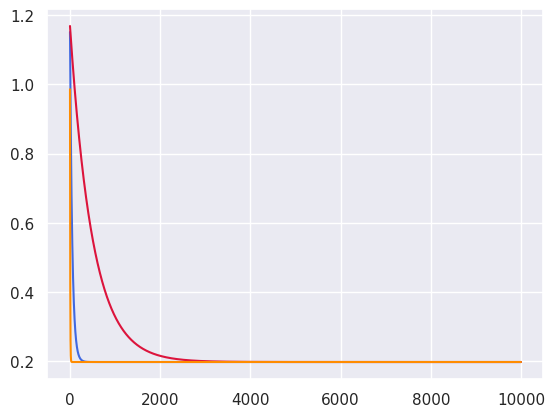

In [44]:
plt.plot(iter_list_1, cost_memo_1, color='royalblue')
plt.plot(iter_list_1, cost_memo_2, color='crimson')
plt.plot(iter_list_1, cost_memo_3, color='darkorange')
plt.show()

From the plot generated by the last block of code, the dark orange line, corresponding to an alpha (learning rate) of 0.1, is the best.

Here's why:

Faster Convergence: It shows the cost decreasing much more rapidly and reaching the minimum cost of 0.1970 within very few iterations (around 100 iterations, as seen in the logs for Lkald167ALwz).
Optimal Learning Rate: An alpha of 0.1 appears to be a good balance for this dataset, allowing the model to take sufficiently large steps to converge quickly without overshooting the minimum or oscillating excessively.
In contrast:

The royalblue line (alpha = 0.01) takes significantly more iterations (around 1000) to reach the same minimum cost.
The crimson line (alpha = 0.001) is much slower and has not yet reached the minimum cost even after 1000 iterations. While it would eventually reach it, it's less efficient.